## Loading the Data

In [12]:
from dipoleska.utils.map_read import MapLoader
from dipoleska.utils.map_process import MapProcessor
from dipoleska.utils.plotting import MapPlotter
from dipoleska.utils.modulated_map_generator import ModulatedMapGenerator
from dipoleska.models.dipole import Dipole

(<MollweideAxes: title={'center': 'Density map'}>,
 <Figure size 1000x630 with 2 Axes>)

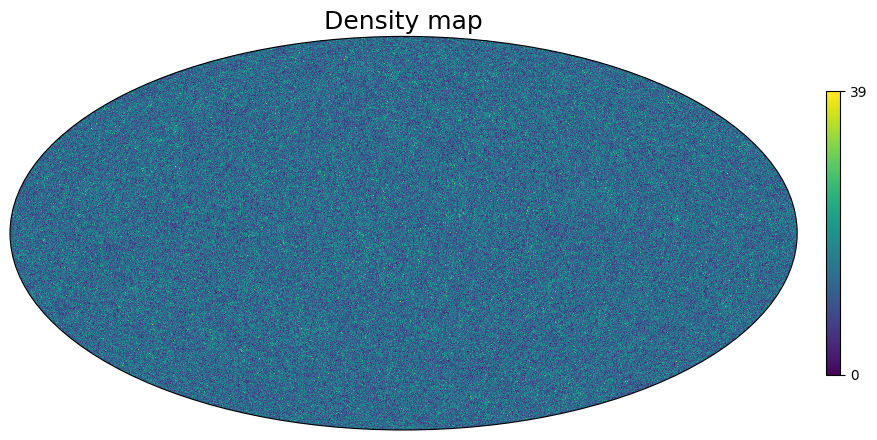

In [8]:
loader = MapLoader(briggs_weighting=1, configuration='AA')
density_map = loader.load(1)
plotter = MapPlotter(density_map)
plotter.plot_density_map()

## Adding a Dipole
To imprint a dipole into the already-discretised SKA map, the basic idea is to use `hp.map2alm` to determine the spherical harmonic coefficients of the map. Then we use `hp.alm2map` to turn these coefficients back into a map, multiply this by a dipole map/signal of form $1 + \mathcal{D} \cos \theta$ and make Poisson draws at each pixel in the multiplied map.

(<MollweideAxes: title={'center': 'Density map'}>,
 <Figure size 1000x630 with 2 Axes>)

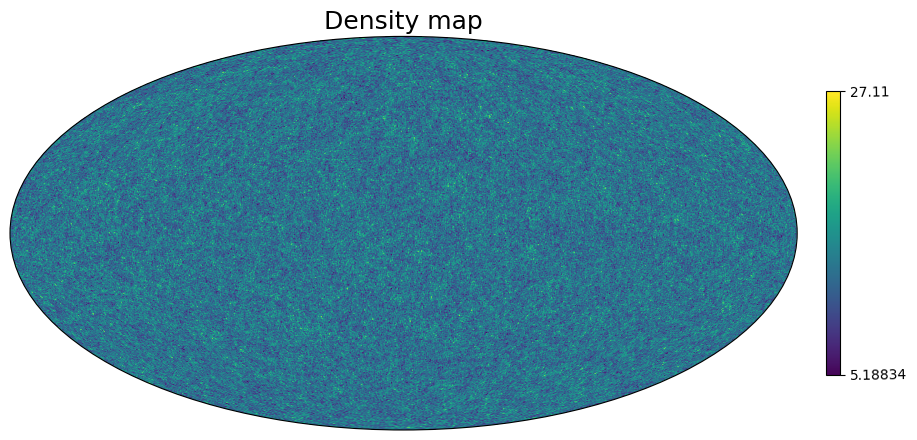

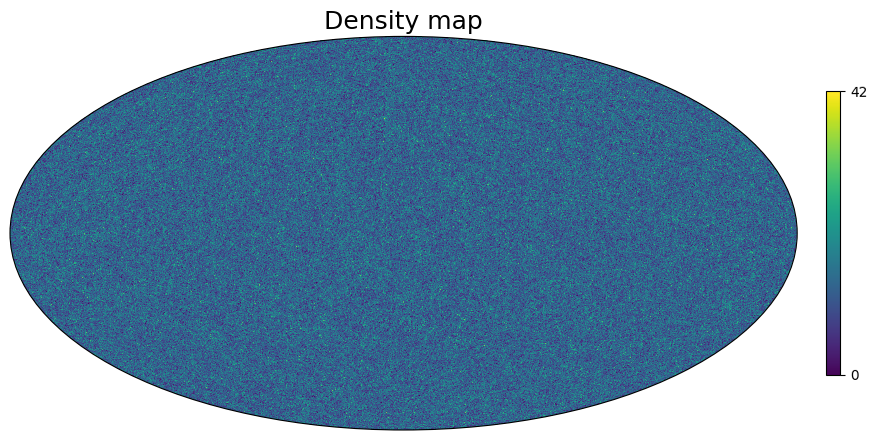

In [9]:
modulator = ModulatedMapGenerator(
    density_map,
    dipole_amplitude=0.005,
    dipole_longitude=180,
    dipole_latitude=-5
)
modulated_map = modulator.modulated_map()

signal_plotter = MapPlotter(modulator.dipole_added_map / modulator.scaling_factor)
signal_plotter.plot_density_map()

modulated_plotter = MapPlotter(modulated_map)
modulated_plotter.plot_density_map()

100%|██████████| 20193/20193 [00:00<00:00, 48689.61it/s]


(<MollweideAxes: title={'center': 'Smoothed density map'}>,
 <Figure size 1000x630 with 2 Axes>)

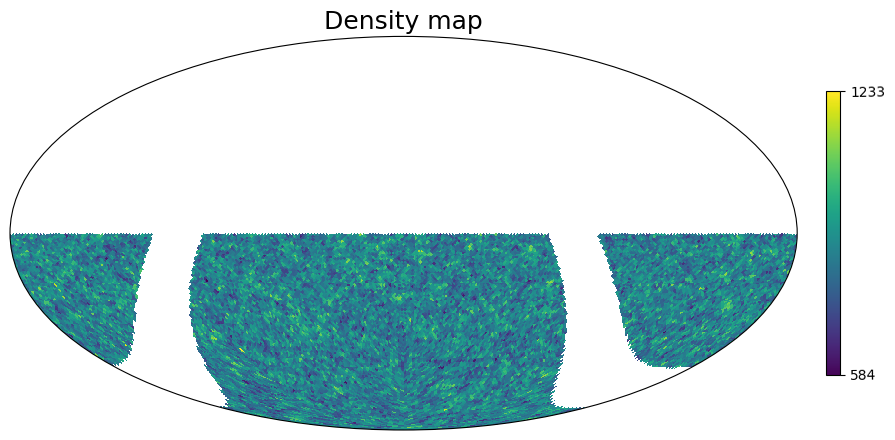

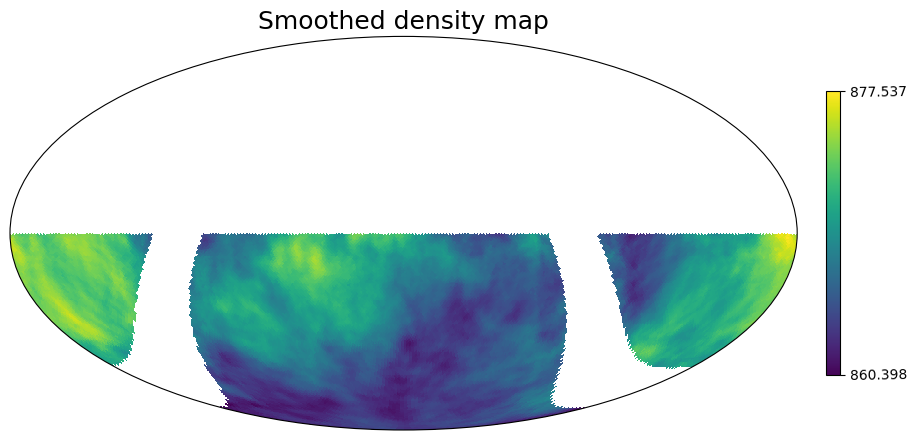

In [10]:
processor = MapProcessor(modulated_map)
processor.change_map_resolution(nside_out=64)
processor.mask(
    classification=['north_equatorial', 'galactic_plane'],
    radius=[90, 10],
    output_frame='C'
)

density_map_final = processor.density_map
plotter = MapPlotter(density_map_final)
plotter.plot_density_map()
plotter.plot_smooth_map()

## Fitting a Dipole

Creating directory for new run ultranest_logs/run49
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-2e+08  7e+08 [-1.737e+08..-1.737e+08]*| it/evals=5880/12164 eff=49.9830% N=400 
[ultranest] Likelihood function evaluations: 12164


/Users/ooay3125/Documents/dipole-ska/.venv/lib/python3.12/site-packages/ultranest/integrator.py:2944: RuntimeWarning: invalid value encountered in scalar power
  results['logzerr_single'] = (main_iterator.all_H[0] / self.min_num_live_points)**0.5


[ultranest] Writing samples and results to disk ...
[ultranest] Writing samples and results to disk ... done
[ultranest]   logZ = -1.737e+08 +- 0.1139
[ultranest] Effective samples strategy satisfied (ESS = 1908.4, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.11, need <0.5)
[ultranest]   logZ error budget: single: 0.05 bs:0.11 tail:0.01 total:0.11 required:<0.50
[ultranest] done iterating.

logZ = -173684149.186 +- 0.202
  single instance: logZ = -173684149.186 +- nan
  bootstrapped   : logZ = -173684149.216 +- 0.202
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    D                   0.00738 +- 0.00075
    phi                 2.33 +- 0.11
    theta               : 0.245 │ ▁ ▁▁▁▁▁▂▃▄▅▆▆▆▇▇▇▆▆▆▄▃▄▂▂▂▁▁▁▁▁▁▁ ▁▁▁ │0.867     0.515 +- 0.079

weights do not sum to 1 (1)


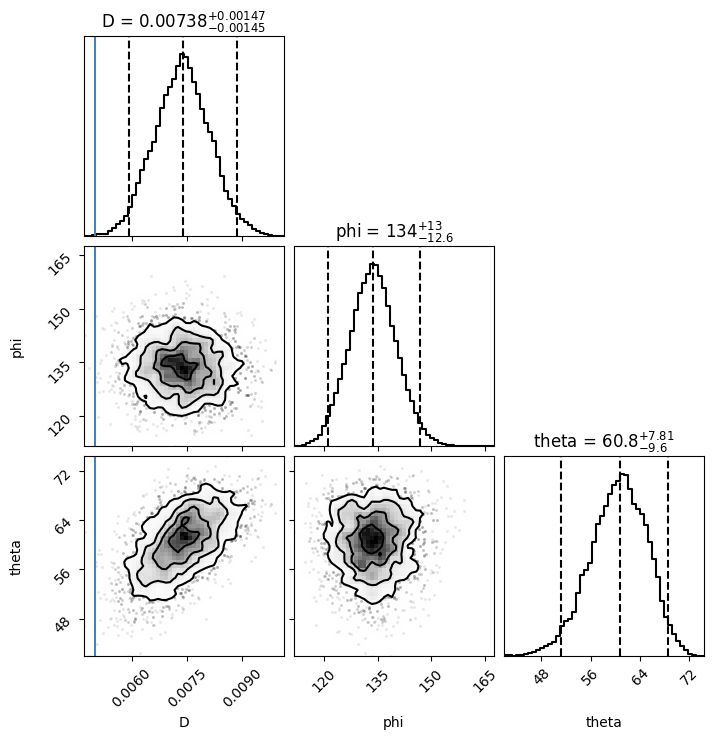

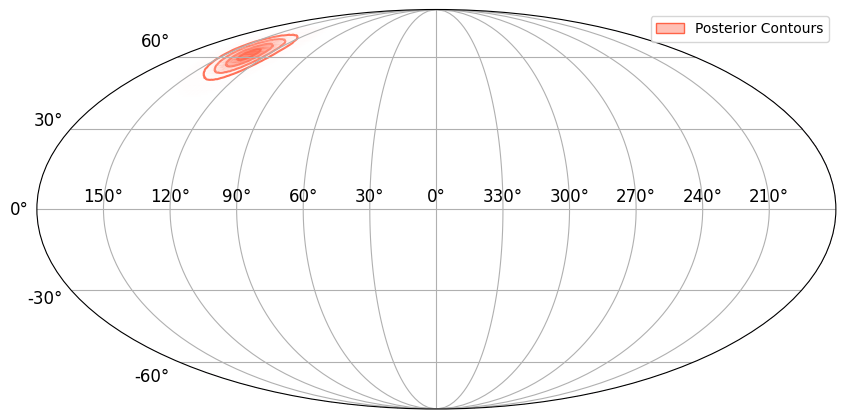

In [15]:
model = Dipole(density_map_final)
model.run_nested_sampling()
model.corner_plot(truths=[0.005, 180, -5], coordinates=['equatorial'])
model.sky_direction_posterior(coordinates=['equatorial'])